In [84]:
import pandas as pd

df = pd.read_csv('household_power_consumption.csv', sep=';', low_memory=False)

print(df.head())


         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


In [85]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,3928


In [86]:
df.shape

(327915, 9)

In [87]:
df=df.tail(1000)

In [88]:
df.shape

(1000, 9)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 326915 to 327914
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   1000 non-null   object 
 1   Time                   1000 non-null   object 
 2   Global_active_power    1000 non-null   object 
 3   Global_reactive_power  1000 non-null   object 
 4   Voltage                1000 non-null   object 
 5   Global_intensity       1000 non-null   object 
 6   Sub_metering_1         1000 non-null   object 
 7   Sub_metering_2         1000 non-null   object 
 8   Sub_metering_3         978 non-null    float64
dtypes: float64(1), object(8)
memory usage: 70.4+ KB


In [90]:
df.columns.str.strip()

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [91]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,22


In [92]:
df["Sub_metering_3"].unique()

array([ 0.,  9., 18., 17., 16., 14.,  4., 11.,  1., nan])

Selecting tail 1000 rows automatically removes null values .

but if there were any null values present what i would do is:
1)find mean at first
2)fill the mean at null values

In [93]:
 a=df["Sub_metering_3"].mean()
 a
df["Sub_metering_3"]=df["Sub_metering_3"].fillna(a)


In [94]:
a

np.float64(5.333333333333333)

In [95]:
df["Sub_metering_3"].unique()

array([ 0.        ,  9.        , 18.        , 17.        , 16.        ,
       14.        ,  4.        , 11.        ,  1.        ,  5.33333333])

If there were any values present beside null values like "abc":
Here is what i would do in that case:


In [96]:
# df["Sub_metering_3"]=df["Sub_metering_3"].replace(["abc"],"a")
# df["Sub_metering_3"]=df["Sub_metering_3"].fillna("a")
# df["Sub_metering_3"].unique()

In [97]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
326915,31/7/2007,17:59:00,0.138,0.000,236.060,0.600,0.000,0.000,0.0
326916,31/7/2007,18:00:00,0.138,0.000,235.840,0.600,0.000,0.000,0.0
326917,31/7/2007,18:01:00,0.138,0.000,235.840,0.600,0.000,0.000,0.0
326918,31/7/2007,18:02:00,0.138,0.000,235.750,0.600,0.000,0.000,0.0
326919,31/7/2007,18:03:00,0.156,0.000,235.890,0.800,0.000,0.000,0.0


In [98]:
# df[["Global_active_power","Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]].unique()##cannot do like this need to do one by one

need to do individually

In [99]:
columns_to_check = ["Global_active_power","Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]

for col in columns_to_check:
    print(f"Unique values for {col}:\n{df[col].unique()}\n")

Unique values for Global_active_power:
['0.138' '0.156' '0.248' '0.244' '0.240' '0.238' '0.236' '0.234' '0.252'
 '0.310' '0.316' '0.606' '0.690' '0.694' '0.718' '0.634' '0.580' '0.602'
 '0.582' '0.816' '0.808' '0.738' '0.714' '0.712' '0.708' '0.706' '0.542'
 '0.432' '0.428' '0.436' '0.366' '0.206' '0.272' '0.312' '0.306' '0.304'
 '0.302' '0.300' '0.298' '0.296' '0.294' '0.258' '0.204' '0.286' '0.552'
 '0.152' '0.140' '0.212' '0.242' '0.948' '1.294' '1.284' '1.268' '1.266'
 '1.264' '1.260' '1.254' '1.248' '1.252' '1.330' '1.328' '1.262' '1.230'
 '1.226' '1.214' '1.212' '1.220' '1.296' '1.288' '1.290' '1.292' '1.298'
 '1.304' '1.380' '1.494' '1.506' '1.436' '1.396' '1.398' '1.416' '1.444'
 '1.492' '3.570' '3.566' '3.698' '3.848' '3.728' '3.624' '3.600' '3.502'
 '3.406' '3.412' '3.072' '1.238' '1.234' '1.456' '1.512' '1.532' '1.552'
 '1.548' '1.554' '1.558' '1.544' '1.560' '1.562' '1.582' '1.656' '1.662'
 '1.664' '1.660' '1.708' '1.732' '1.694' '1.704' '1.698' '1.700' '1.682'
 '1.678' '1.

In [100]:
#  b=df["Sub_metering_2"].mean()
#  b
# df["Sub_metering_2"]=df["Sub_metering_2"].fillna(b)


In [101]:
df["Sub_metering_2"].unique()

array(['0.000', '?'], dtype=object)

In [102]:
df.shape

(1000, 9)

In [103]:
columns_to_convert = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 326915 to 327914
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   1000 non-null   object 
 1   Time                   1000 non-null   object 
 2   Global_active_power    979 non-null    float64
 3   Global_reactive_power  979 non-null    float64
 4   Voltage                979 non-null    float64
 5   Global_intensity       979 non-null    float64
 6   Sub_metering_1         979 non-null    float64
 7   Sub_metering_2         979 non-null    float64
 8   Sub_metering_3         1000 non-null   float64
dtypes: float64(7), object(2)
memory usage: 70.4+ KB
None


There may arise n/a or stray text  so  coerce forces that string to be replaced by NAN.

First, let's combine the 'Date' and 'Time' columns into a new column called 'datetime'.

To prepare our data for time series forecasting, we first need to combine the `Date` and `Time` columns into a single `datetime` column. Then, we will convert this column to the proper datetime data type and set it as the DataFrame's index. Finally, we'll extract useful time-based features for our model.

In [104]:


 # Combine 'Date' and 'Time' into a new 'datetime_col' string column
df['datetime_col'] = df['Date'] + ' ' + df['Time']

# 2. Converting the new 'datetime_col' to actual datetime objects
df['datetime_col'] = pd.to_datetime(df['datetime_col'], dayfirst=True)

# 3. Set 'datetime_col' as the DataFrame's index and remove original Date/Time columns
df = df.set_index('datetime_col')#date time col is set as an index in here
df = df.drop(columns=['Date', 'Time'])

# 4. Feature Engineering: Extract time-based features
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek # Monday=0, Sunday=6
df['hour'] = df.index.hour


print(df.info())

print(df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1000 entries, 2007-07-31 17:59:00 to 2007-08-01 10:38:00
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    979 non-null    float64
 1   Global_reactive_power  979 non-null    float64
 2   Voltage                979 non-null    float64
 3   Global_intensity       979 non-null    float64
 4   Sub_metering_1         979 non-null    float64
 5   Sub_metering_2         979 non-null    float64
 6   Sub_metering_3         1000 non-null   float64
 7   year                   1000 non-null   int32  
 8   month                  1000 non-null   int32  
 9   day                    1000 non-null   int32  
 10  day_of_week            1000 non-null   int32  
 11  hour                   1000 non-null   int32  
dtypes: float64(7), int32(5)
memory usage: 82.0 KB
None
                     Global_active_power  Global_reactive_power  Voltage 

In [105]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,year,month,day,day_of_week,hour
datetime_col,,,,,,,,,,,,
2007-07-31 17:59:00,0.138,0.0,236.06,0.6,0.0,0.0,0.0,2007,7,31,1,17
2007-07-31 18:00:00,0.138,0.0,235.84,0.6,0.0,0.0,0.0,2007,7,31,1,18
2007-07-31 18:01:00,0.138,0.0,235.84,0.6,0.0,0.0,0.0,2007,7,31,1,18
2007-07-31 18:02:00,0.138,0.0,235.75,0.6,0.0,0.0,0.0,2007,7,31,1,18
2007-07-31 18:03:00,0.156,0.0,235.89,0.8,0.0,0.0,0.0,2007,7,31,1,18




To understand the temporal dynamics of power consumption, let's visualize `Global_active_power` against its `datetime` index. This will help us identify trends, seasonality, and any unusual spikes or dips ETCccccc

In [106]:
import matplotlib.pyplot as plt


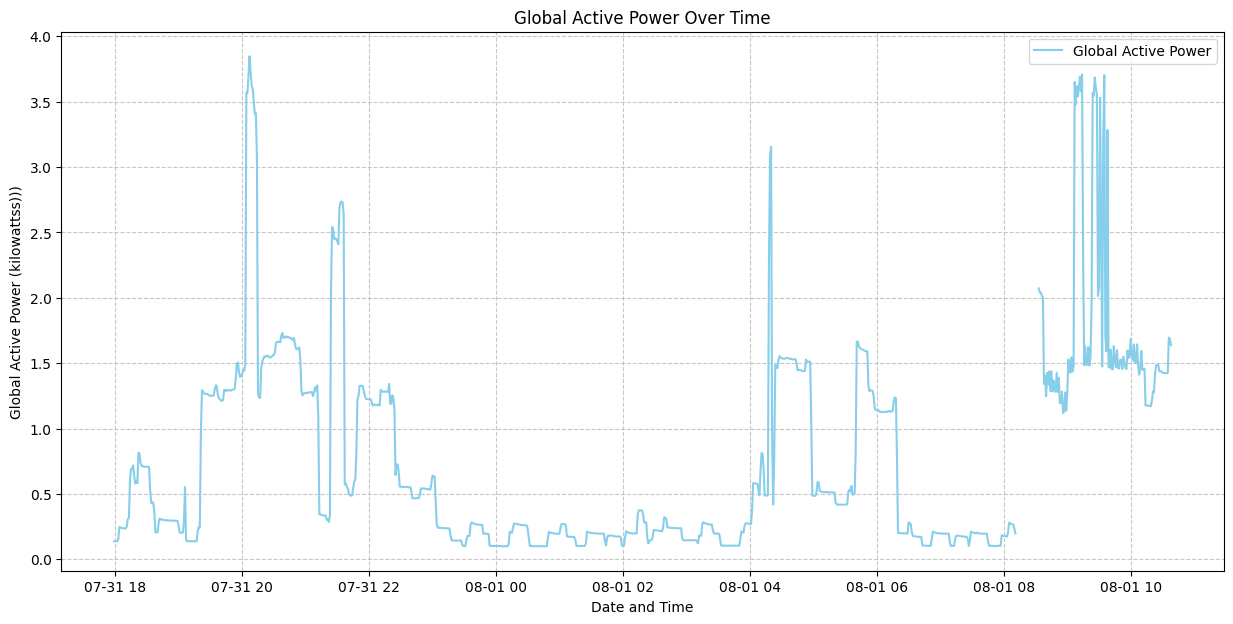

In [107]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Global_active_power'], label='Global Active Power', color='skyblue')
plt.title('Global Active Power Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power (kilowattss)))')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

This plot helps us see the overall trend. now to ses if there are any clear daily or weekly patterns, using the features we extracted earlier.


 visualizing the distribution of the `Global_active_power` column using a histogram. This will give us an idea of the typical power consumption values and their frequency.

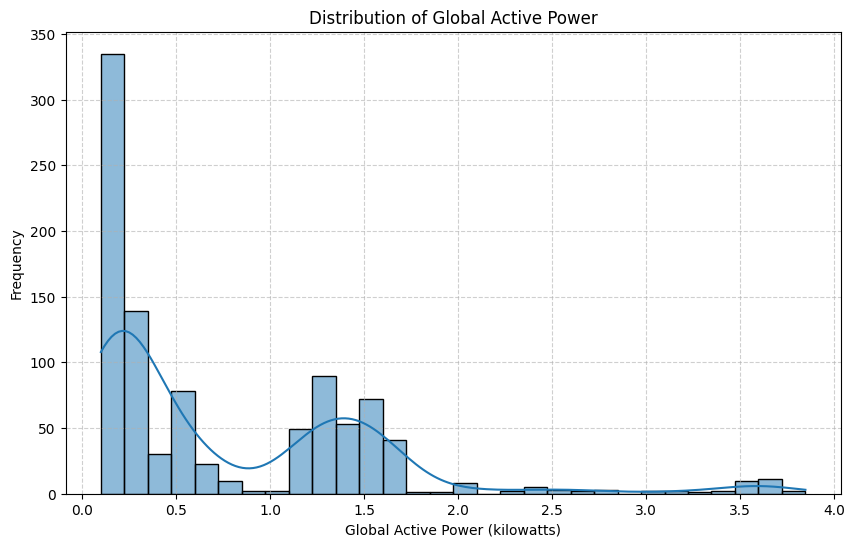

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Global_active_power'], bins=30, kde=True)
plt.title('Distribution of Global Active Power')
plt.xlabel('Global Active Power (kilowatts)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

 descriptive statistics for `Global_active_power` to understand its central tendency, spread, and shape.

In [109]:
print(df['Global_active_power'].describe())

count    979.000000
mean       0.779238
std        0.776050
min        0.100000
25%        0.196000
50%        0.420000
75%        1.294000
max        3.848000
Name: Global_active_power, dtype: float64


 Correlation Analysis of Numerical Features

To understand the relationships between the different power consumption metrics, let's calculate and visualize their correlation matrix.

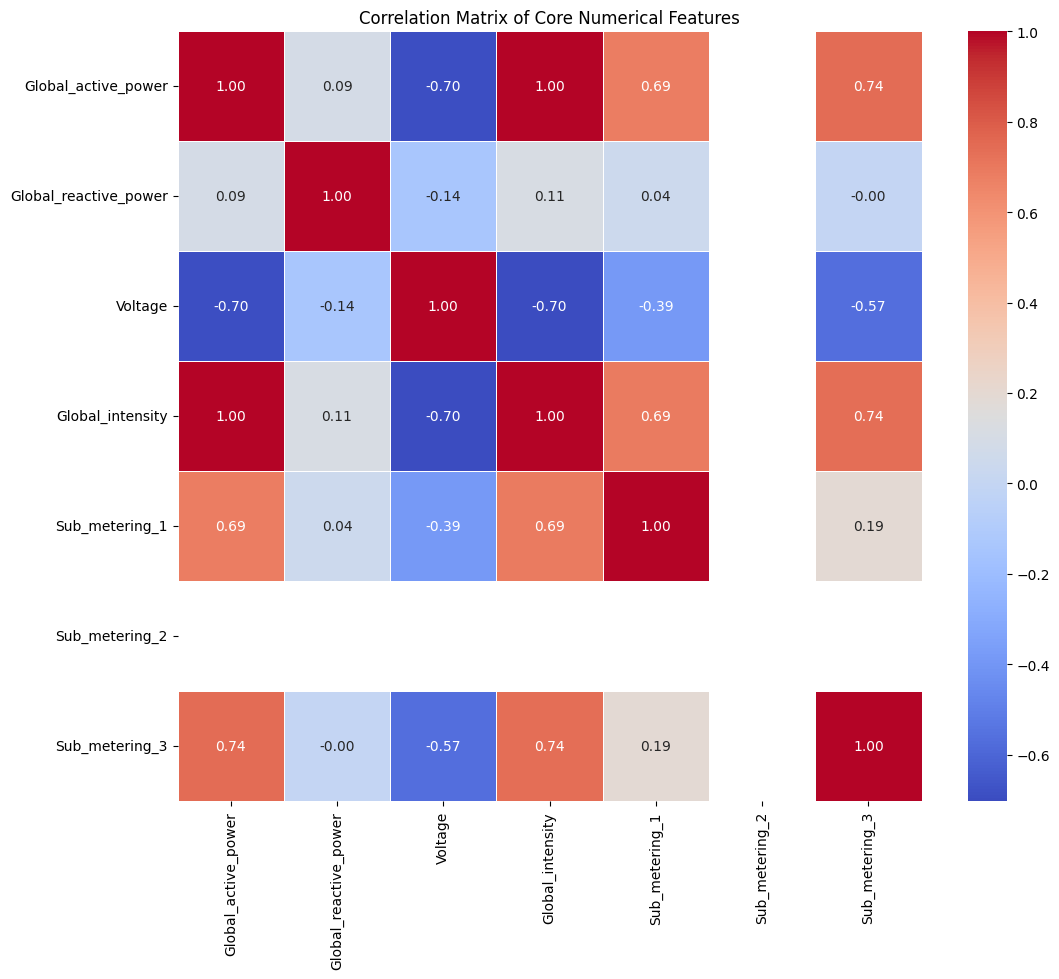

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting only the coree numerical columns for correlation calculation,
# excluding the engineered time features (year, month, day, day_of_week, hour)
columns_for_correlation = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
numerical_df = df[columns_for_correlation]

# Calculatedd the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Core Numerical Features')
plt.show()

#

In [111]:
# First, let's see how many data points we have and over what time period.
print(f"Original DataFrame shape: {df.shape}")
print(f"Start time: {df.index.min()}")
print(f"End time: {df.index.max()}")


df_resampled = df.resample('min').mean()
for col in ['year', 'month', 'day', 'day_of_week', 'hour']:
    df_resampled[col] = df_resampled[col].ffill().bfill().astype(int)

#For the actual power columns, we will interpolate to fill any newly created NaN values
columns_to_interpolate = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

for col in columns_to_interpolate:
    df_resampled[col] = df_resampled[col].interpolate(method='linear')

# After resampling and interpolation, let's check for any remaining missing values
print("\nMissing values after resampling and interpolation:")
print(df_resampled.isnull().sum())

print(f"\nResampled DataFrame shape: {df_resampled.shape}")
print(f"Start time (resampled): {df_resampled.index.min()}")
print(f"End time (resampled): {df_resampled.index.max()}")

# Let's update our main dataframe 'df' to be the resampled one
df = df_resampled.copy()

print("\nDataFrame after handling missing timestamps and regularization (first 5 rows):")
display(df.head())

Original DataFrame shape: (1000, 12)
Start time: 2007-07-31 17:59:00
End time: 2007-08-01 10:38:00

Missing values after resampling and interpolation:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
year                     0
month                    0
day                      0
day_of_week              0
hour                     0
dtype: int64

Resampled DataFrame shape: (1000, 12)
Start time (resampled): 2007-07-31 17:59:00
End time (resampled): 2007-08-01 10:38:00

DataFrame after handling missing timestamps and regularization (first 5 rows):


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,year,month,day,day_of_week,hour
datetime_col,,,,,,,,,,,,
2007-07-31 17:59:00,0.138,0.0,236.06,0.6,0.0,0.0,0.0,2007,7,31,1,17
2007-07-31 18:00:00,0.138,0.0,235.84,0.6,0.0,0.0,0.0,2007,7,31,1,18
2007-07-31 18:01:00,0.138,0.0,235.84,0.6,0.0,0.0,0.0,2007,7,31,1,18
2007-07-31 18:02:00,0.138,0.0,235.75,0.6,0.0,0.0,0.0,2007,7,31,1,18
2007-07-31 18:03:00,0.156,0.0,235.89,0.8,0.0,0.0,0.0,2007,7,31,1,18


  Outlier Detection plus Treatment (Z-score Analysis)


In [112]:
from scipy.stats import zscore
import numpy as np

# These are the columns where we want to look for outliers if there are any
columns_to_check_outliers = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

# Our 'rule' for what's too far from the average. If a number is more than 3 'steps' away, it's an outlier.
z_score_threshold = 3

print(f"Looking for outliers where Z-score is greater than {z_score_threshold}:\n")

# Let's go through each  columnto find outliers
for col in columns_to_check_outliers:
    # Calculate the Z-score for each number in the column. We take the 'abs' (absolute) value
    df[f'zscore_{col}'] = np.abs(zscore(df[col]))

    # Find all the rows where the Z-score for this column is bigger than threshold
    outliers = df[df[f'zscore_{col}'] > z_score_threshold]

    # If we found any strange numbers, let's print them out
    if not outliers.empty:
        print(f" Outliers found in '{col}'")
        print(f"Number of outliers: {len(outliers)}")
        # Show the weird numbers and their Z-scores
        display(outliers[[col, f'zscore_{col}']].head())
    else:
        print(f" No outliers found in '{col}' with Z-score > {z_score_threshold}")

# removing the zscore columns after checking them to keep our dataframe clean
df = df.drop(columns=[col for col in df.columns if col.startswith('zscore_')])

print("\nFinished checking for outliers using Z-score.")

Looking for outliers where Z-score is greater than 3:

 Outliers found in 'Global_active_power'
Number of outliers: 28


,Global_active_power,zscore_Global_active_power
datetime_col,,
2007-07-31 20:04:00,3.570,3.601645
2007-07-31 20:05:00,3.566,3.596469
2007-07-31 20:06:00,3.698,3.767280
2007-07-31 20:07:00,3.848,3.961384
2007-07-31 20:08:00,3.728,3.806101


 Outliers found in 'Global_reactive_power'
Number of outliers: 2


,Global_reactive_power,zscore_Global_reactive_power
datetime_col,,
2007-07-31 18:22:00,0.396,3.956373
2007-07-31 18:23:00,0.388,3.849626


 Outliers found in 'Voltage'
Number of outliers: 10


...

 Outliers found in 'Global_intensity'
Number of outliers: 29


,Global_intensity,zscore_Global_intensity
datetime_col,,
2007-07-31 20:04:00,15.2,3.582983
2007-07-31 20:05:00,15.2,3.582983
2007-07-31 20:06:00,15.8,3.765357
2007-07-31 20:07:00,16.4,3.947731
2007-07-31 20:08:00,15.8,3.765357


 Outliers found in 'Sub_metering_1'
Number of outliers: 41


,Sub_metering_1,zscore_Sub_metering_1
datetime_col,,
2007-07-31 20:04:00,35.0,4.725860
2007-07-31 20:05:00,36.0,4.867484
2007-07-31 20:06:00,36.0,4.867484
2007-07-31 20:07:00,37.0,5.009108
2007-07-31 20:08:00,37.0,5.009108


 No outliers found in 'Sub_metering_2' with Z-score > 3
 No outliers found in 'Sub_metering_3' with Z-score > 3

Finished checking for outliers using Z-score.


In [113]:
daily_pattern = df.groupby('hour')['Global_active_power'].mean()
daily_pattern

,Global_active_power
hour,
0,0.164900
1,0.175900
2,0.227267
3,0.175600
4,1.218267
5,0.802333
6,0.495000
7,0.162333
8,1.088683


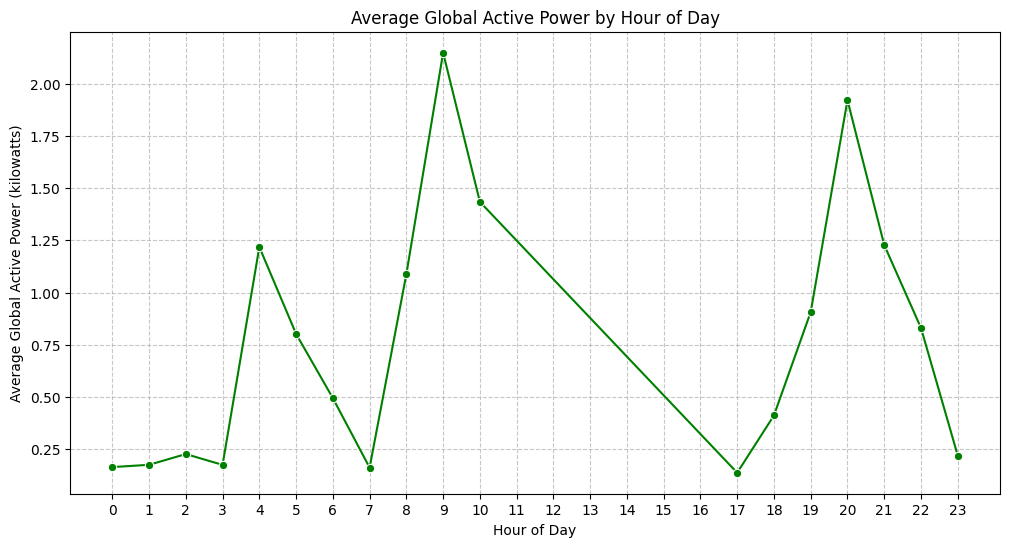

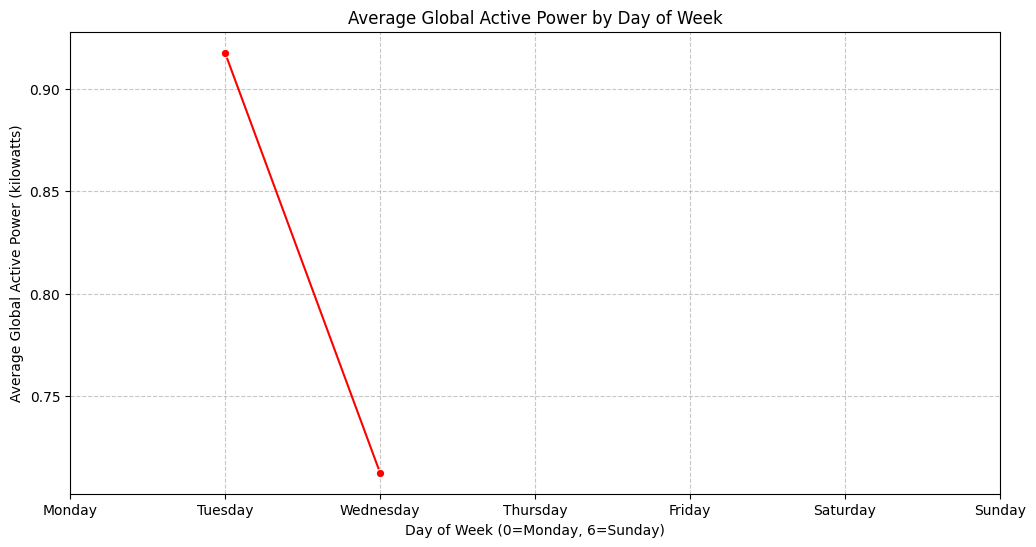

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by hour to see daily patterns
daily_pattern = df.groupby('hour')['Global_active_power'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_pattern.index, y=daily_pattern.values, marker='o', color='green')
plt.title('Average Global Active Power by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kilowatts)')
plt.xticks(range(24)) # Show all hours from 0 to 23
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Group by day of week to see weekly patterns
# Day of week is 0=Monday, 6=Sunday
weekly_pattern = df.groupby('day_of_week')['Global_active_power'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=weekly_pattern.index, y=weekly_pattern.values, marker='o', color='red')
plt.title('Average Global Active Power by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Global Active Power (kilowatts)')
plt.xticks(range(7), ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Daily and Weekly Patterns of Global Active Power

To understand the typical behavior of power consumption, let's SEE the average `Global_active_power` across different hours of the day and different days of the week. This will reveal daily cycles and weekly variations, which are crucial for time series forecasting.

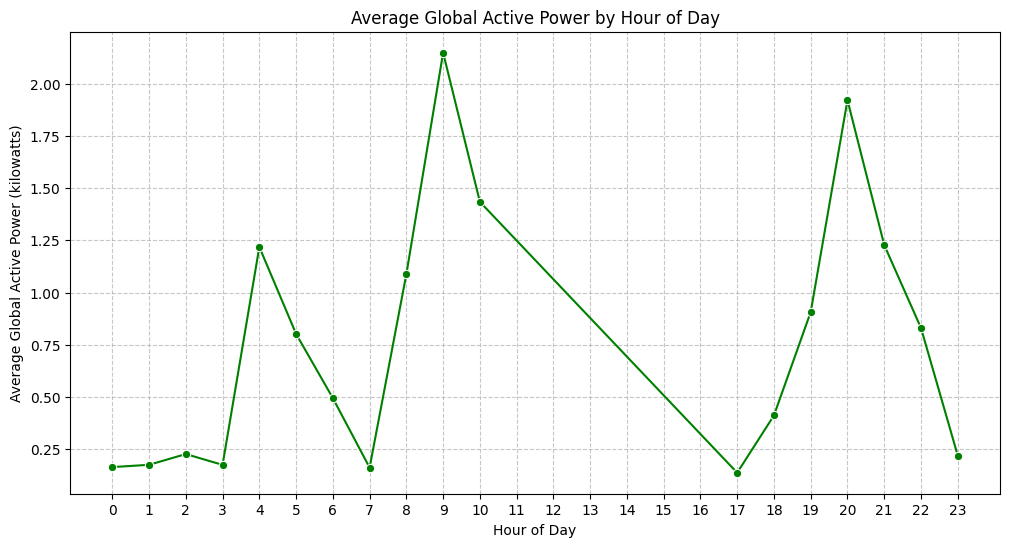

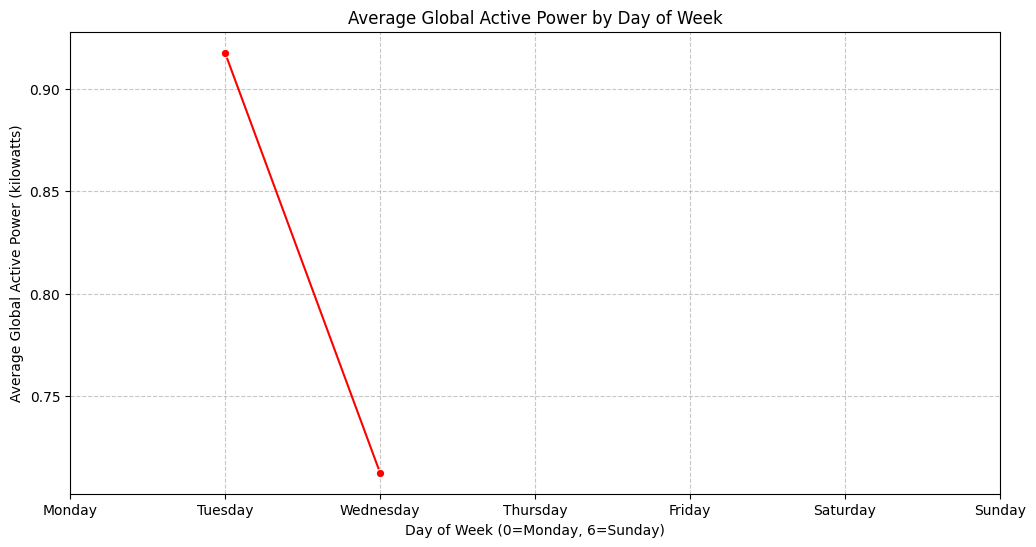

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by hour to see daily patterns
daily_pattern = df.groupby('hour')['Global_active_power'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_pattern.index, y=daily_pattern.values, marker='o', color='green')
plt.title('Average Global Active Power by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kilowatts)')
plt.xticks(range(24)) # Show all hours from 0 to 23
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Group by day of week to see weekly patterns
# Day of week is 0=Monday, 6=Sunday
weekly_pattern = df.groupby('day_of_week')['Global_active_power'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=weekly_pattern.index, y=weekly_pattern.values, marker='o', color='red')
plt.title('Average Global Active Power by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Global Active Power (kilowatts)')
plt.xticks(range(7), ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

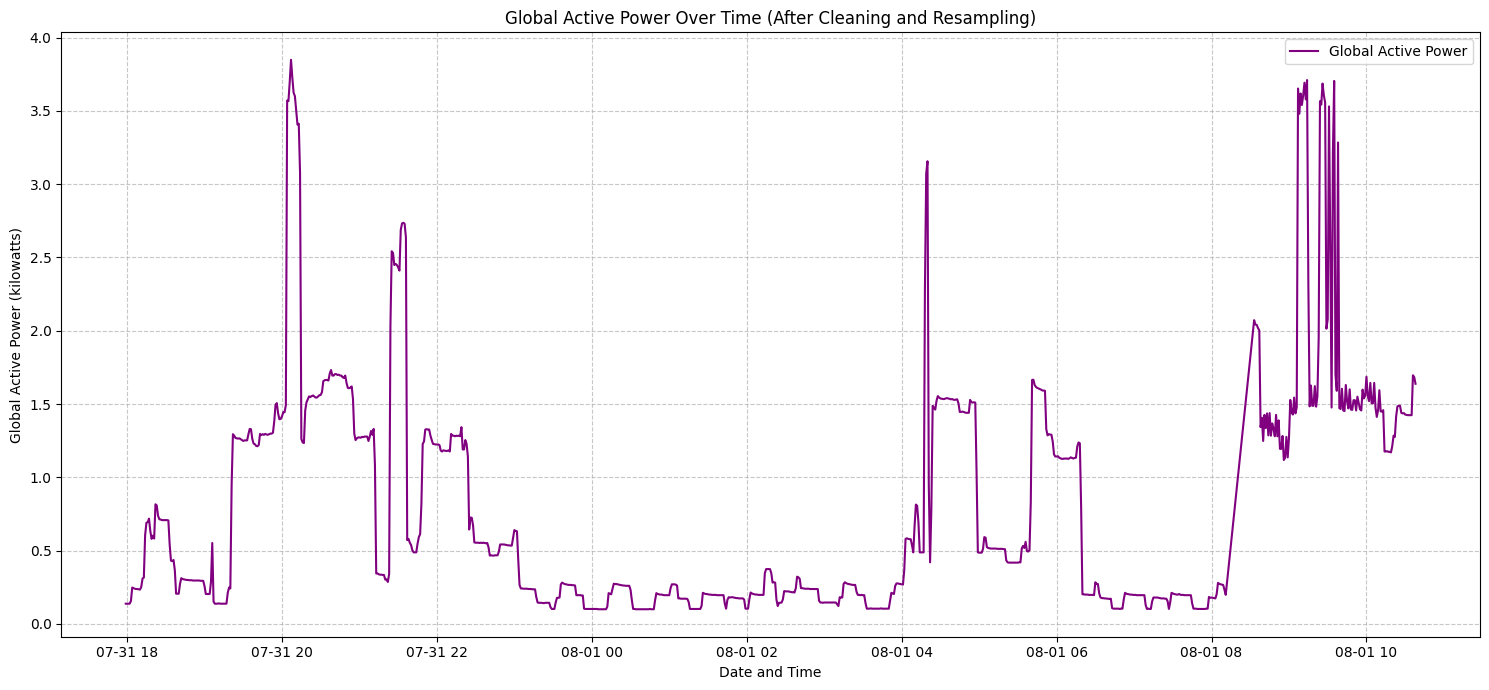

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Global_active_power'], label='Global Active Power', color='purple')
plt.title('Global Active Power Over Time (After Cleaning and Resampling)')
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power (kilowatts)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

 Autocorrelation and Partial Autocorrelation Analysis

Just overview

  Autocorrelation Function (ACF) tells us the direct and indirect relationship between an observation and observations at previous time steps.   *Partial Autocorrelation Function (PACF)*tells us the direct relationship between an observation and an observation at a previous time step, after removing the influence of intermediate observations.



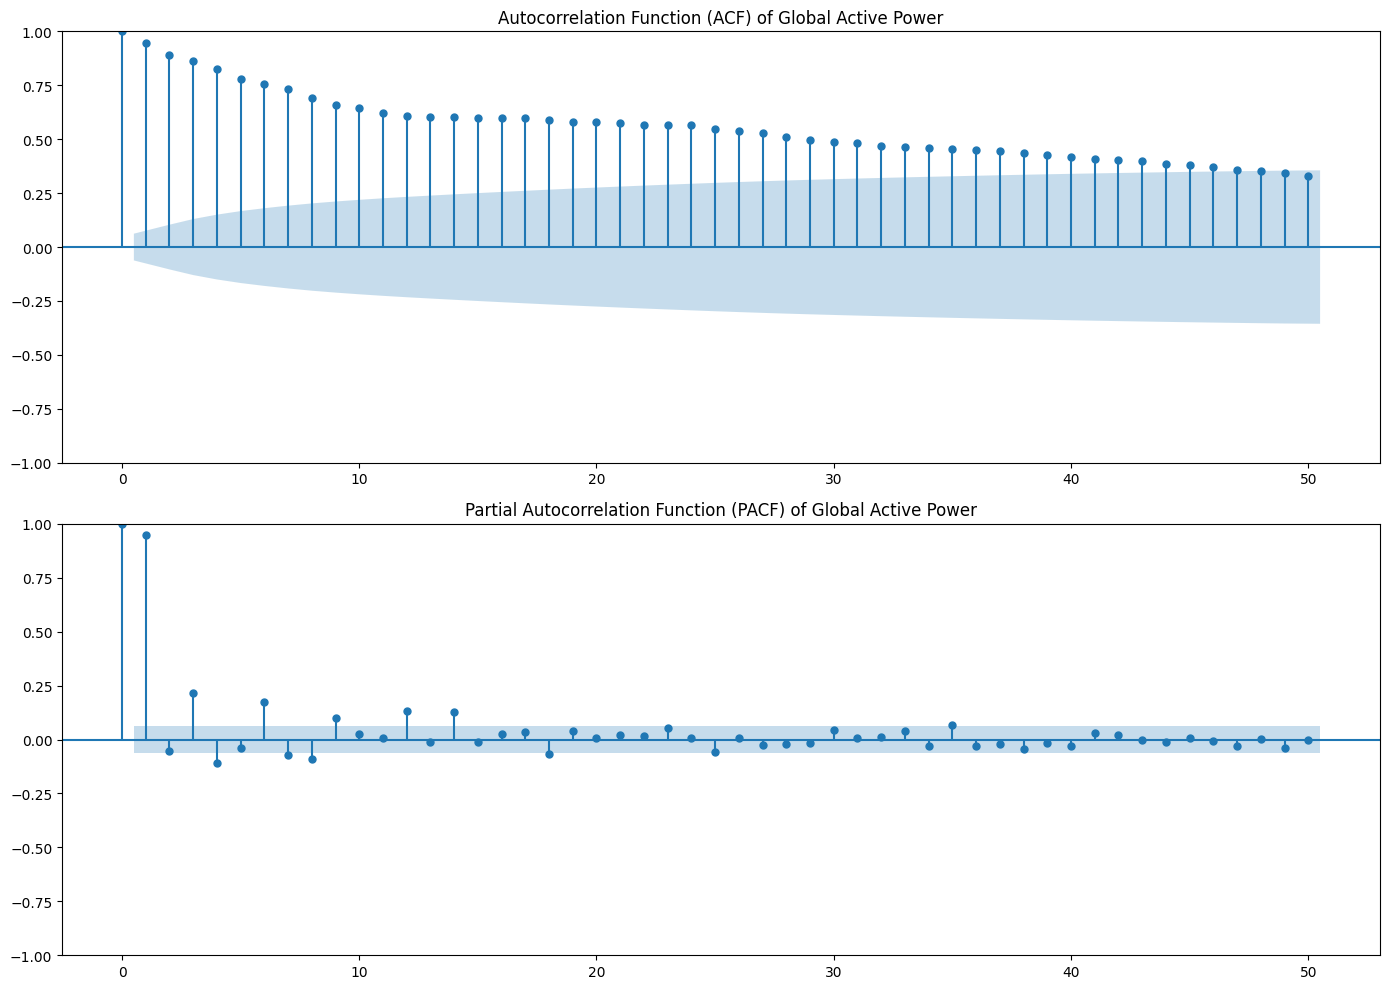

In [117]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


plt.figure(figsize=(14, 10))

# Plot the Autocorrelation Function (ACF)
plt.subplot(2, 1, 1) # 2 rows, 1 column, 1st plot it is
plot_acf(df['Global_active_power'], lags=50, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Global Active Power')

# Plot the Partial Autocorrelation Function (PACF)
plt.subplot(2, 1, 2) # 2 rows, 1 column, 2nd plot
plot_pacf(df['Global_active_power'], lags=50, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) of Global Active Power')

plt.tight_layout()#prevents labels titles and other plot elements from overlapping
plt.show()

MODEL TRAINING PART-----------=============----====-=-=========-=-=-

In [118]:
# 1. Data Splitting: Training and Validation Sets
# target variable (what we want to predict)
target_variable = 'Global_active_power'

# Create a new DataFrame with only the target variable for splitting
df_model = df[[target_variable]].copy()

# Calculate the split point for an 80/20 split
split_point = int(len(df_model) * 0.8)

# Split the data into training and testing sets chronologically
train_df = df_model.iloc[:split_point].copy()
test_df = df_model.iloc[split_point:].copy()

print(f"Total data points: {len(df_model)}")
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(test_df)}")

print("\nFirst 5 rows of training data:")
print(train_df.head())

print("\nFirst 5 rows of validation data:")
print(test_df.head())

Total data points: 1000
Training set size: 800
Validation set size: 200

First 5 rows of training data:
                     Global_active_power
datetime_col                            
2007-07-31 17:59:00                0.138
2007-07-31 18:00:00                0.138
2007-07-31 18:01:00                0.138
2007-07-31 18:02:00                0.138
2007-07-31 18:03:00                0.156

First 5 rows of validation data:
                     Global_active_power
datetime_col                            
2007-08-01 07:19:00                0.178
2007-08-01 07:20:00                0.176
2007-08-01 07:21:00                0.174
2007-08-01 07:22:00                0.174
2007-08-01 07:23:00                0.174


In [119]:
from prophet import Prophet

# 2. Algorithm Selection: Prophet - Training

#training data for Prophet
# include 'datetime_col' (as 'ds') and 'Global_active_power' (as 'y')
prophet_df_train = train_df.reset_index()[['datetime_col', 'Global_active_power']].rename(columns={'datetime_col': 'ds', 'Global_active_power': 'y'})

# Display the head of the prepared DataFrame to confirm structure
print("Prepared training data for Prophet (only ds and y):")
display(prophet_df_train.head())

# Instantiate the Prophet model
# No extra regressors are being added here at first lets see if need it laterr
model = Prophet()

# Fit the model to the training data
model.fit(prophet_df_train)


Prepared training data for Prophet (only ds and y):


,ds,y
0,2007-07-31 17:59:00,0.138
1,2007-07-31 18:00:00,0.138
2,2007-07-31 18:01:00,0.138
3,2007-07-31 18:02:00,0.138
4,2007-07-31 18:03:00,0.156


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet forecast generated successfully. Displaying head of forecast:
                   ds      yhat  yhat_lower  yhat_upper
0 2007-08-01 07:19:00  0.512528   -0.074928    1.183504
1 2007-08-01 07:20:00  0.511114   -0.056467    1.107658
2 2007-08-01 07:21:00  0.509700   -0.079286    1.162102
3 2007-08-01 07:22:00  0.508287   -0.094646    1.104616
4 2007-08-01 07:23:00  0.506873   -0.129430    1.098887

Model Evaluation on Test Set:
Mean Absolute Error (MAE): 1.073
Mean Squared Error (MSE): 1.781
Root Mean Squared Error (RMSE): 1.335


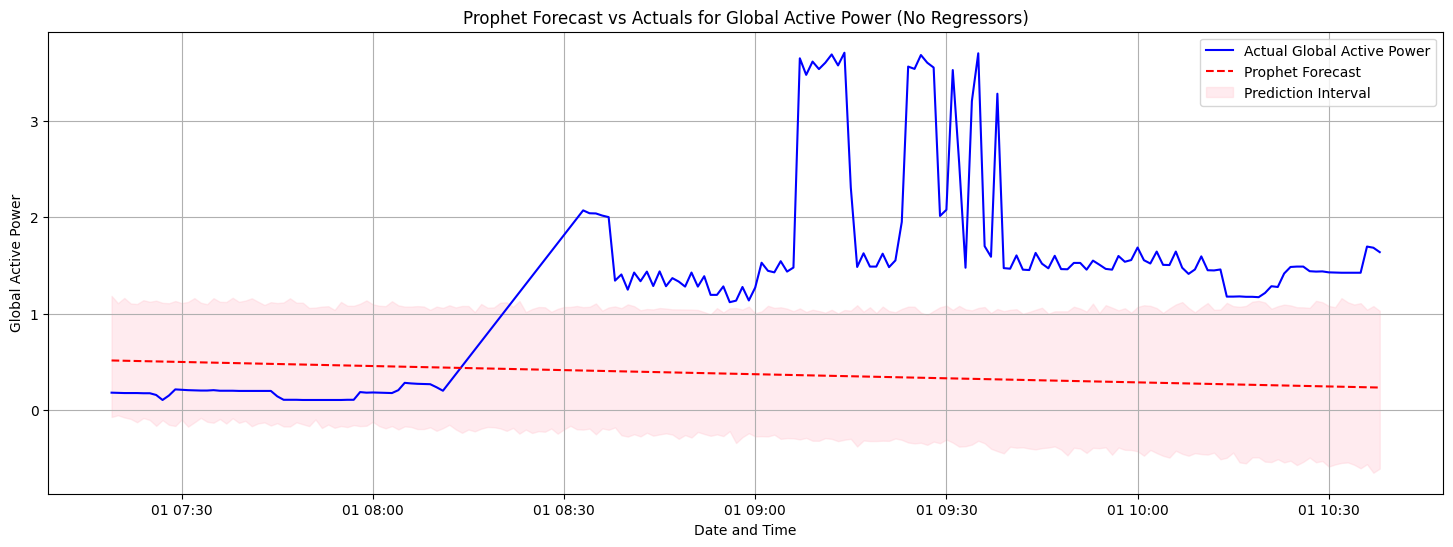

In [120]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 3. Model Evaluation: Making Predictions and Checking Performance

# Prepare the test data for Prophet predictions
# For forecasting without extra regressors, Prophet only needs the 'ds' column from the future dates.
future = test_df.reset_index()[['datetime_col']].rename(columns={'datetime_col': 'ds'})

# Make predictions
forecast = model.predict(future)

print("Prophet forecast generated successfully. Displaying head of forecast:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

# Merge actual values from test_df with the forecast for evaluation
forecast_merged = pd.merge(test_df.reset_index(), forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], left_on='datetime_col', right_on='ds', how='left')

# Evaluate the model
y_true = forecast_merged['Global_active_power']
y_pred = forecast_merged['yhat']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

# Plotting the forecast against actual values
plt.figure(figsize=(18, 6))
plt.plot(forecast_merged['datetime_col'], forecast_merged['Global_active_power'], label='Actual Global Active Power', color='blue')
plt.plot(forecast_merged['datetime_col'], forecast_merged['yhat'], label='Prophet Forecast', color='red', linestyle='--')
plt.fill_between(forecast_merged['datetime_col'], forecast_merged['yhat_lower'], forecast_merged['yhat_upper'], color='pink', alpha=0.3, label='Prediction Interval')
plt.title('Prophet Forecast vs Actuals for Global Active Power (No Regressors)')
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power')
plt.legend()
plt.grid(True)
plt.show()

NOW WE ADD REGRESSOR AND DO THE TASK AGAIN BECAUSE error  IS too much

In [121]:
import pandas as pd

target_variable = 'Global_active_power'


input_features = [
    'Global_intensity',
    'Sub_metering_3',
    'Voltage',
    'hour',
    'day_of_week',
    'month'
]


# Create a new DataFrame containing only the target and input features
df_model = df[[target_variable] + input_features].copy()

# Calculate the split point for an 80/20 split
split_point = int(len(df_model) * 0.8)

# Split the data into training and testing sets
train_df = df_model.iloc[:split_point].copy()
test_df = df_model.iloc[split_point:].copy()

print(f"Total data points: {len(df_model)}")
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(test_df)}")

print("\nFirst 5 rows of training data:")
display(train_df.head())

print("\nFirst 5 rows of validation data:")
display(test_df.head())

Total data points: 1000
Training set size: 800
Validation set size: 200

First 5 rows of training data:


,Global_active_power,Global_intensity,Sub_metering_3,Voltage,hour,day_of_week,month
datetime_col,,,,,,,
2007-07-31 17:59:00,0.138,0.6,0.0,236.06,17,1,7
2007-07-31 18:00:00,0.138,0.6,0.0,235.84,18,1,7
2007-07-31 18:01:00,0.138,0.6,0.0,235.84,18,1,7
2007-07-31 18:02:00,0.138,0.6,0.0,235.75,18,1,7
2007-07-31 18:03:00,0.156,0.8,0.0,235.89,18,1,7



First 5 rows of validation data:


,Global_active_power,Global_intensity,Sub_metering_3,Voltage,hour,day_of_week,month
datetime_col,,,,,,,
2007-08-01 07:19:00,0.178,0.8,0.0,237.48,7,2,8
2007-08-01 07:20:00,0.176,0.8,0.0,237.58,7,2,8
2007-08-01 07:21:00,0.174,0.8,0.0,237.89,7,2,8
2007-08-01 07:22:00,0.174,0.8,0.0,237.89,7,2,8
2007-08-01 07:23:00,0.174,0.8,0.0,238.12,7,2,8


In [122]:
from prophet import Prophet


input_features = [
    'Global_intensity',
    'Sub_metering_3',
    'Voltage',
    'hour',
    'day_of_week',
    'month'
]


prophet_df_train = train_df.reset_index()[['datetime_col', 'Global_active_power'] + input_features].rename(columns={'datetime_col': 'ds', 'Global_active_power': 'y'})

# Display the head of the prepared DataFrame
print("Prepared training data for Prophet (with regressors):")
print(prophet_df_train.head())

# startimg Prophet model
model = Prophet()

# Add the input features as extra regressors
for feature in input_features:
    model.add_regressor(feature)

# Fit the model to the training data
model.fit(prophet_df_train)

print("\nProphet model fitted successfully with additional regressors.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prepared training data for Prophet (with regressors):
                   ds      y  Global_intensity  Sub_metering_3  Voltage  hour  \
0 2007-07-31 17:59:00  0.138               0.6             0.0   236.06    17   
1 2007-07-31 18:00:00  0.138               0.6             0.0   235.84    18   
2 2007-07-31 18:01:00  0.138               0.6             0.0   235.84    18   
3 2007-07-31 18:02:00  0.138               0.6             0.0   235.75    18   
4 2007-07-31 18:03:00  0.156               0.8             0.0   235.89    18   

   day_of_week  month  
0            1      7  
1            1      7  
2            1      7  
3            1      7  
4            1      7  

Prophet model fitted successfully with additional regressors.


Prophet forecast generated successfully. Displaying head of forecast:


,ds,yhat,yhat_lower,yhat_upper
0,2007-08-01 07:19:00,0.166565,0.127709,0.203769
1,2007-08-01 07:20:00,0.166394,0.126275,0.205641
2,2007-08-01 07:21:00,0.166018,0.128213,0.207027
3,2007-08-01 07:22:00,0.165945,0.127122,0.208534
4,2007-08-01 07:23:00,0.165647,0.127597,0.206432



Model Evaluation on Test Set:
Mean Absolute Error (MAE): 0.025
Mean Squared Error (MSE): 0.002
Root Mean Squared Error (RMSE): 0.041


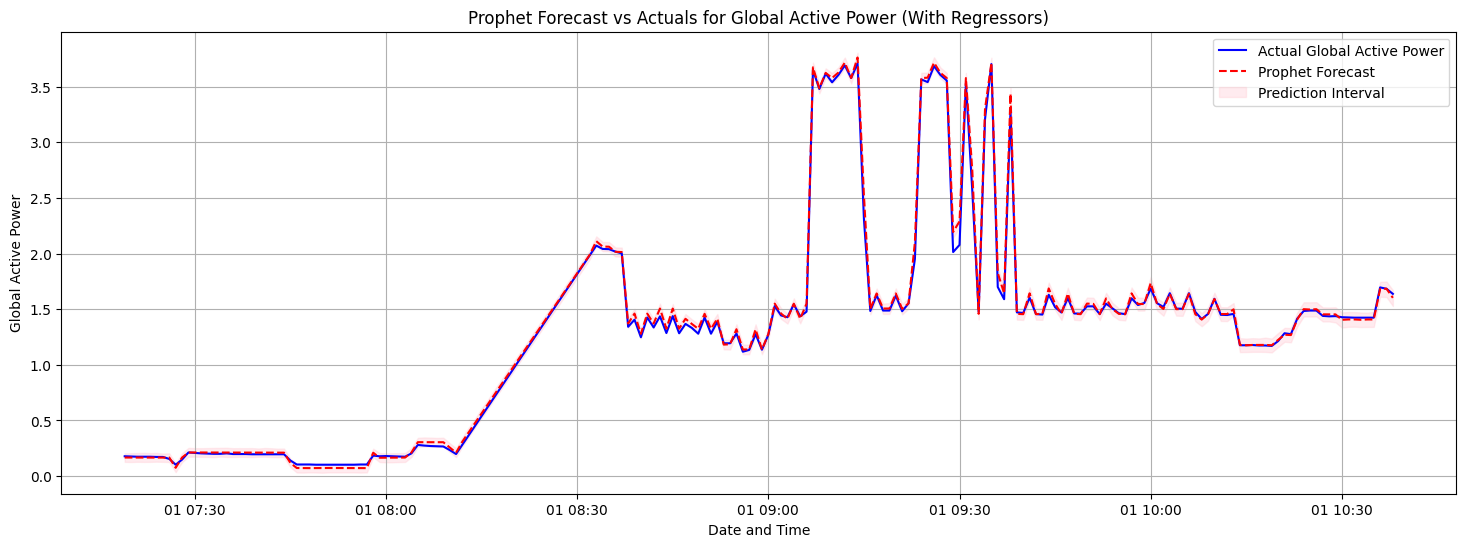

In [123]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error


input_features = [
    'Global_intensity',
    'Sub_metering_3',
    'Voltage',
    'hour',
    'day_of_week',
    'month'
]


future = test_df.reset_index()[['datetime_col'] + input_features].rename(columns={'datetime_col': 'ds'})

# Make predictions
forecast = model.predict(future)

print("Prophet forecast generated successfully. Displaying head of forecast:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())


forecast_merged = pd.merge(test_df.reset_index(), forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], left_on='datetime_col', right_on='ds', how='left')

# Evaluate the model

y_true = forecast_merged['Global_active_power']
y_pred = forecast_merged['yhat']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

# Plotting the forecast against actual values
plt.figure(figsize=(18, 6))
plt.plot(forecast_merged['datetime_col'], forecast_merged['Global_active_power'], label='Actual Global Active Power', color='blue')
plt.plot(forecast_merged['datetime_col'], forecast_merged['yhat'], label='Prophet Forecast', color='red', linestyle='--')
plt.fill_between(forecast_merged['datetime_col'], forecast_merged['yhat_lower'], forecast_merged['yhat_upper'], color='pink', alpha=0.3, label='Prediction Interval')
plt.title('Prophet Forecast vs Actuals for Global Active Power (With Regressors)')
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power')
plt.legend()
plt.grid(True)
plt.show()

GOT little bit extra BETTER PERFORMANCE AFTER USING REGRESSOR RATHER THAN NOT USING REGRESSOR...

ETS algorithm selection............

Fitting ETS model
ETS model fitted successfully.
                       ExponentialSmoothing Model Results                       
Dep. Variable:      Global_active_power   No. Observations:                  800
Model:             ExponentialSmoothing   SSE                             29.848
Optimized:                         True   AIC                          -2622.796
Trend:                         Additive   BIC                          -2604.058
Seasonal:                          None   AICC                         -2622.690
Seasonal Periods:                  None   Date:                 Mon, 30 Mar 2026
Box-Cox:                          False   Time:                         06:48:28
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha       

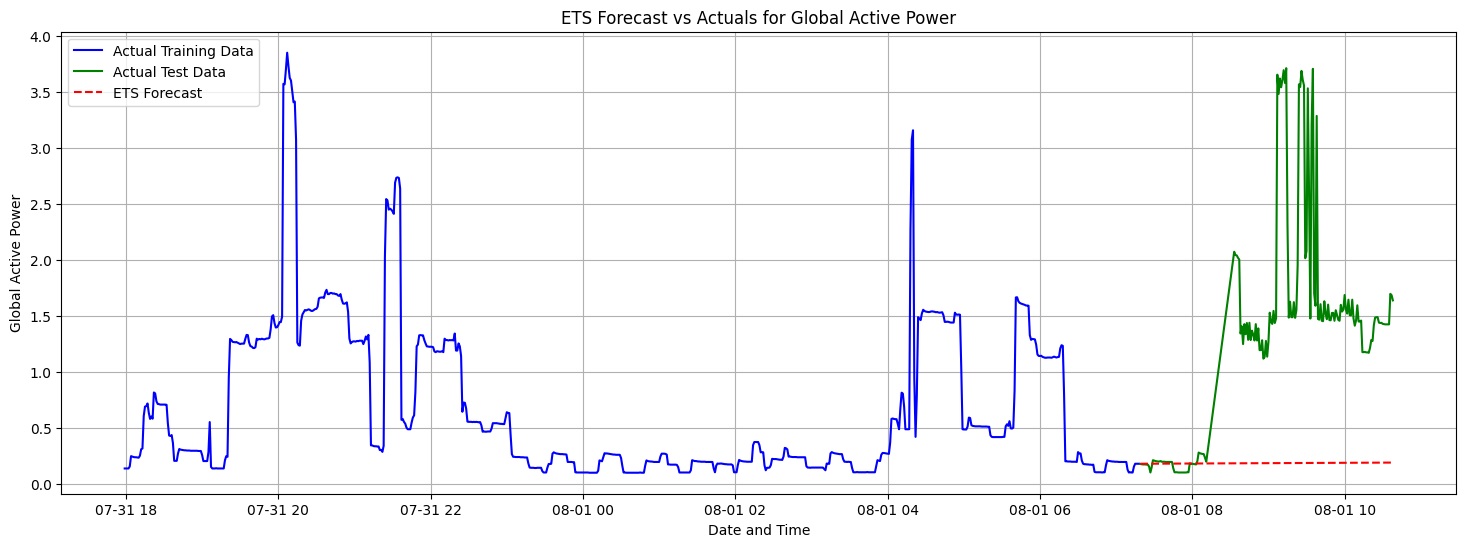

In [124]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Corrected import
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


y_train = train_df['Global_active_power']
y_test = test_df['Global_active_power']

print("Fitting ETS model")

ets_model = ExponentialSmoothing(y_train, trend='add', seasonal=None, damped_trend=False) # Changed ETS to ExponentialSmoothing

# Fit the model
fit_ets = ets_model.fit()

print("ETS model fitted successfully.")
print(fit_ets.summary())

# Make predictions on the test set
forecast_ets = fit_ets.forecast(steps=len(y_test))
#steps=len(y_test): This argument specifies how many future time steps the model should forecast.

# Evaluate the model
mae_ets = mean_absolute_error(y_test, forecast_ets)
mse_ets = mean_squared_error(y_test, forecast_ets)
rmse_ets = np.sqrt(mse_ets)

print(f"\nModel Evaluation on Test Set (ETS):")
print(f"Mean Absolute Error (MAE): {mae_ets:.3f}")
print(f"Mean Squared Error (MSE): {mse_ets:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ets:.3f}")

# Plotting the forecast against actual values
plt.figure(figsize=(18, 6))
plt.plot(y_train.index, y_train, label='Actual Training Data', color='blue')
plt.plot(y_test.index, y_test, label='Actual Test Data', color='green')
plt.plot(y_test.index, forecast_ets, label='ETS Forecast', color='red', linestyle='--')
plt.title('ETS Forecast vs Actuals for Global Active Power')
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power')
plt.legend()
plt.grid(True)
plt.show()

Fitting ETS model...
ETS model fitted successfully.
                       ExponentialSmoothing Model Results                       
Dep. Variable:      Global_active_power   No. Observations:                  800
Model:             ExponentialSmoothing   SSE                             29.848
Optimized:                         True   AIC                          -2622.796
Trend:                         Additive   BIC                          -2604.058
Seasonal:                          None   AICC                         -2622.690
Seasonal Periods:                  None   Date:                 Mon, 30 Mar 2026
Box-Cox:                          False   Time:                         06:48:28
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha    

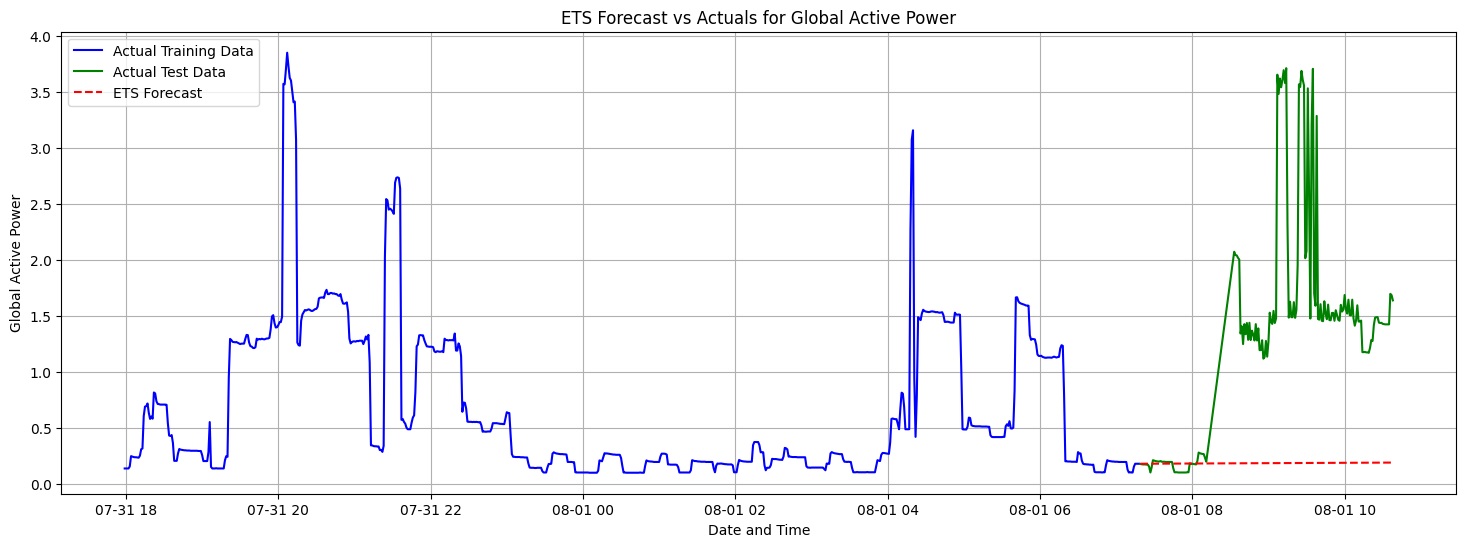

In [125]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Corrected import
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


y_train = train_df['Global_active_power']
y_test = test_df['Global_active_power']

print("Fitting ETS model...")

ets_model = ExponentialSmoothing(y_train, trend='add', seasonal=None, damped_trend=False) # Changed ETS to ExponentialSmoothing

# Fit the model
fit_ets = ets_model.fit()

print("ETS model fitted successfully.")
print(fit_ets.summary())

# Make predictions on the test set
forecast_ets = fit_ets.forecast(steps=len(y_test))

# Evaluate the model
mae_ets = mean_absolute_error(y_test, forecast_ets)
mse_ets = mean_squared_error(y_test, forecast_ets)
rmse_ets = np.sqrt(mse_ets)

print(f"\nModel Evaluation on Test Set (ETS):")
print(f"Mean Absolute Error (MAE): {mae_ets:.3f}")
print(f"Mean Squared Error (MSE): {mse_ets:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ets:.3f}")

# Plotting the forecast against actual values
plt.figure(figsize=(18, 6))
plt.plot(y_train.index, y_train, label='Actual Training Data', color='blue')
plt.plot(y_test.index, y_test, label='Actual Test Data', color='green')
plt.plot(y_test.index, forecast_ets, label='ETS Forecast', color='red', linestyle='--')
plt.title('ETS Forecast vs Actuals for Global Active Power')
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power')
plt.legend()
plt.grid(True)
plt.show()

Since Prophet's output (yhat) is a continuous number, standard classification metrics like 'accuracy score', 'precision', 'recall', or 'F1-score' (which are part of a 'classification report') are not directly applicable or meaningful in this case

Now time for cross validation and performance metrics

INFO:prophet:Making 6 forecasts with cutoffs between 2007-08-01 00:18:00 and 2007-08-01 05:18:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7d41682e4350>


Data for Prophet (prophet_df_train) prepared.

Starting Prophet hyperparameter tuning with cross-validation...

Testing params: cps=0.001, sps=0.01, daily_seasonality=False


INFO:prophet:Making 6 forecasts with cutoffs between 2007-08-01 00:18:00 and 2007-08-01 05:18:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7d41681b00b0>


  -> Avg RMSE: 0.709, Avg MAE: 0.581

Testing params: cps=0.001, sps=0.01, daily_seasonality=True


INFO:prophet:Making 6 forecasts with cutoffs between 2007-08-01 00:18:00 and 2007-08-01 05:18:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7d416afe04d0>


...

INFO:prophet:Making 6 forecasts with cutoffs between 2007-08-01 00:18:00 and 2007-08-01 05:18:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7d4186ee5d30>


  -> Avg RMSE: 0.685, Avg MAE: 0.470

Testing params: cps=0.5, sps=10.0, daily_seasonality=True


INFO:prophet:Making 6 forecasts with cutoffs between 2007-08-01 00:18:00 and 2007-08-01 05:18:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7d4184811c10>


  -> Avg RMSE: 4.510, Avg MAE: 3.115

--- Prophet Model Tuning Results (No Regressors) ---
    changepoint_prior_scale  seasonality_prior_scale  daily_seasonality  \
27                    0.500                     0.10               True   
3                     0.001                     0.10               True   
25                    0.500                     0.01               True   
1                     0.001                     0.01               True   
9                     0.010                     0.01               True   
11                    0.010                     0.10               True   
15                    0.010                    10.00               True   
13                    0.010                     1.00               True   
24                    0.500                     0.01              False   
26                    0.500                     0.10              False   
28                    0.500                     1.00              False   
30       

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


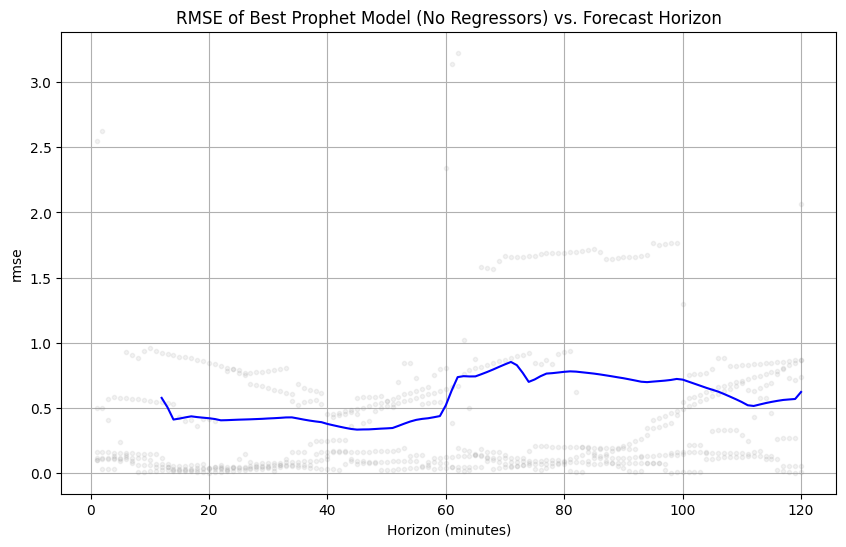

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


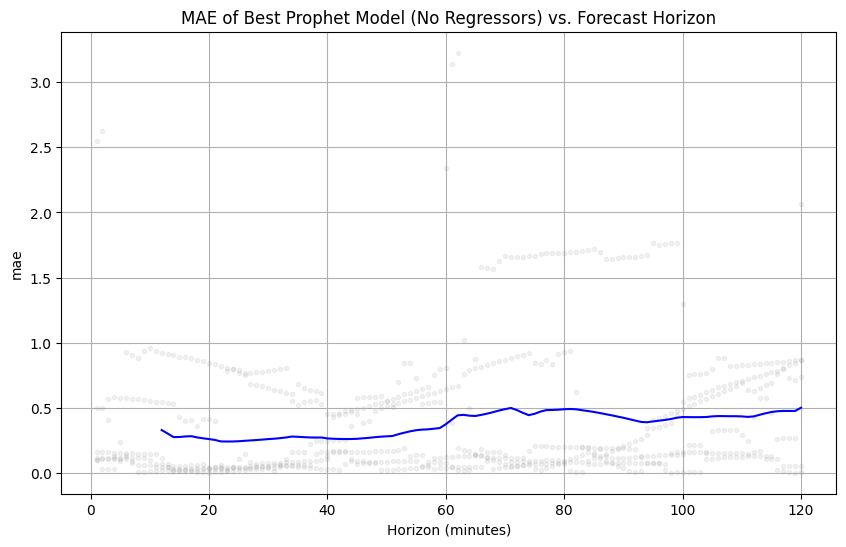

In [126]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



target_variable = 'Global_active_power'
df_model = df[[target_variable]].copy()
split_point = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_point].copy()
prophet_df_train = train_df.reset_index()[['datetime_col', 'Global_active_power']].rename(columns={'datetime_col': 'ds', 'Global_active_power': 'y'})

print("Data for Prophet (prophet_df_train) prepared.")

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'daily_seasonality': [False, True], # Given the data is in   minutes, daily is relevant
    'weekly_seasonality': [False], # Not enough data for weekly
    'yearly_seasonality': [False]  # Not enough data for yearly
}

all_results_prophet = []
best_rmse_prophet = float('inf')
best_mae_prophet = float('inf')
best_params_prophet = None
best_df_cv = None

print("\nStarting Prophet hyperparameter tuning with cross-validation...")

# Iterate over all parameter combinations
for cps in param_grid['changepoint_prior_scale']:
    for sps in param_grid['seasonality_prior_scale']:
        for ds in param_grid['daily_seasonality']:
            print(f"\nTesting params: cps={cps}, sps={sps}, daily_seasonality={ds}")

            model_tuned = Prophet(
                changepoint_prior_scale=cps,
                seasonality_prior_scale=sps,
                daily_seasonality=ds,
                weekly_seasonality=False,
                yearly_seasonality=False # Explicitly set to False
            )

            # Fit the model
            model_tuned.fit(prophet_df_train)

            # Perform cross-validation
            # Use parameters similar to previous cross-validation setup for consistency
            try:
                df_cv_tuned = cross_validation(
                    model_tuned,
                    initial='360 minutes',
                    period='60 minutes',
                    horizon='120 minutes', # Forecast horizon is 2 hours (120 minutes)
                    parallel="processes"
                )

                # Calculate performance metrics, focusing on the last horizon for a single score
                df_p_tuned = performance_metrics(df_cv_tuned, metrics=['rmse', 'mae'])

                # Average RMSE and MAE over the horizon
                avg_rmse = df_p_tuned['rmse'].mean()
                avg_mae = df_p_tuned['mae'].mean()

                all_results_prophet.append({
                    'changepoint_prior_scale': cps,
                    'seasonality_prior_scale': sps,
                    'daily_seasonality': ds,
                    'avg_rmse': avg_rmse,
                    'avg_mae': avg_mae
                })

                if avg_rmse < best_rmse_prophet:
                    best_rmse_prophet = avg_rmse
                    best_mae_prophet = avg_mae
                    best_params_prophet = {'changepoint_prior_scale': cps, 'seasonality_prior_scale': sps, 'daily_seasonality': ds}
                    best_df_cv = df_cv_tuned # Store for plotting best model performance

                print(f"  -> Avg RMSE: {avg_rmse:.3f}, Avg MAE: {avg_mae:.3f}")

            except Exception as e:
                print(f"  -> Error during cross-validation for these parameters: {e}")
                continue

# to show all tuning results
results_df_prophet = pd.DataFrame(all_results_prophet).sort_values(by='avg_rmse')
print("\n--- Prophet Model Tuning Results (No Regressors) ---")
print(results_df_prophet)

print(f"\nBest Prophet model (no regressors) parameters: {best_params_prophet}")
print(f"Best Avg RMSE: {best_rmse_prophet:.3f}")
print(f"Best Avg MAE: {best_mae_prophet:.3f}")

# Plot performance metrics for the best model
if best_df_cv is not None:
    print("\nPlotting performance for the best Prophet model (RMSE and MAE over horizon)...")
    fig_rmse = plot_cross_validation_metric(best_df_cv, metric='rmse')
    plt.title('RMSE of Best Prophet Model (No Regressors) vs. Forecast Horizon')
    plt.show()

    fig_mae = plot_cross_validation_metric(best_df_cv, metric='mae')
    plt.title('MAE of Best Prophet Model (No Regressors) vs. Forecast Horizon')
    plt.show()
else:
    print("No successful cross-validation results to plot.")


Head of prophet

In [130]:
prophet_df_train.head()

,ds,y
0,2007-07-31 17:59:00,0.138
1,2007-07-31 18:00:00,0.138
2,2007-07-31 18:01:00,0.138
3,2007-07-31 18:02:00,0.138
4,2007-07-31 18:03:00,0.156


In [128]:
import pickle

# Open a file in write-binary mode
with open('prophet_model_with_regressors.pkl', 'wb') as f:
    # Use pickle.dump() to save the trained Prophet model object
    pickle.dump(model, f)

print("Trained Prophet model (with regressors) saved successfully to 'prophet_model_with_regressors.pkl'")

Trained Prophet model (with regressors) saved successfully to 'prophet_model_with_regressors.pkl'


In [129]:
min_power = df['Global_active_power'].min()
max_power = df['Global_active_power'].max()

print(f"Minimum Global Active Power: {min_power:.3f} kW")
print(f"Maximum Global Active Power: {max_power:.3f} kW")

Minimum Global Active Power: 0.100 kW
Maximum Global Active Power: 3.848 kW
